# Fenix Android: paid acquisition diagnosis

Investigating a sharp rise in Mobile DAU that began in April 2026, hypothesized to be driven by paid marketing. The Fenix data exposes several paid-attribution signals that disagree in magnitude — using only one will undersell the campaign. This notebook combines them.

## Signals and what they capture

| Signal | What it catches | Granularity |
|---|---|---|
| `paid_vs_organic_gclid = 'Paid'` | Google Play install referrer carried a `gclid` (Google Ads click). Broadest "this install was paid" indicator. | Per-install |
| `install_source = 'com.android.vending'` | Installed from Google Play (with or without paid attribution). Used as the "Other Playstore" complement to `Paid`. | Per-install |
| `adjust_network = 'Google Ads ACI'` | Adjust SDK attribution to Google App Campaigns for Installs (a specific paid product). Smaller volumes, but the cleanest campaign-launch timestamp. | Per-install |

## Acquisition buckets (mirrors STMO [query 116179](https://sql.telemetry.mozilla.org/queries/116179))
- **Paid Playstore** — gclid='Paid'
- **Other Playstore** — Play Store install without gclid (could include lost-gclid paid; mostly organic discovery)
- **Other Android** — sideloads, alternative app stores, partnership preloads

Tables: `moz-fx-data-shared-prod.fenix_derived.profile_dau_metrics_marketing_geo_testing_v1` (DAU; gclid-only) and `moz-fx-data-shared-prod.fenix.new_profiles` (new profiles; full attribution; no reporting lag).

Related dashboard: [Mobile DAU Investigation — March 2026](https://sql.telemetry.mozilla.org/dashboards/2677-mobile-dau-investigation-march-2026). Berry's March framing was "organic falling, paid flat"; the April–May story is the opposite.

iOS mirrors this structure but has no `paid_vs_organic_gclid` — use `adjust_network` on iOS.


In [26]:
# [setup]
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from google.cloud import bigquery

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Analysis window — 2026 series
DATE_START = '2026-02-01'                       # extended (2 months of pre-campaign baseline)
DATE_END = '2026-05-16'                         # latest available
BASELINE_START = pd.Timestamp('2026-02-01')
BASELINE_END = pd.Timestamp('2026-03-28')       # ~8 weeks before campaign launch
CAMPAIGN_LAUNCH = pd.Timestamp('2026-04-06')    # dated from the Adjust ACI new-profile spike

# Prior-year comparison window — 2025, same calendar dates, shifted +52 weeks
# for weekday-aligned overlay on the 2026 axis.
PRIOR_DATE_START = '2025-01-25'                 # extra week of slack on both sides
PRIOR_DATE_END = '2025-05-23'                   # for safe 52-week alignment
YEAR_AGO_OFFSET = pd.Timedelta(weeks=52)        # 364 days; preserves weekday-of-week

BQ_PROJECT = 'moz-fx-data-bq-data-science'
CHANNEL = 'release'

DAU_TABLE = 'moz-fx-data-shared-prod.fenix_derived.profile_dau_metrics_marketing_geo_testing_v1'
NEW_PROFILE_TABLE = 'moz-fx-data-shared-prod.fenix.new_profiles'

client = bigquery.Client(project=BQ_PROJECT)

# Consistent palette across plots
PAID_COLOR = 'C3'      # red
ORGANIC_COLOR = 'C0'   # blue
NULL_COLOR = 'C7'      # grey
PRIOR_YEAR_COLOR = '0.55'  # mid grey for 2025 reference lines


def _split_years(df, date_col='date'):
    """Split a 2-year long-format df into (current_year, prior_year_aligned).
    prior_year_aligned has its date index shifted forward by YEAR_AGO_OFFSET so
    it overlays on the 2026 calendar (weekday-aligned)."""
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    current = df[df[date_col] >= pd.Timestamp(DATE_START)].set_index(date_col).sort_index()
    prior = df[df[date_col] <  pd.Timestamp(DATE_START)].set_index(date_col).sort_index()
    prior.index = prior.index + YEAR_AGO_OFFSET
    return current, prior


def _summarize_yoy(current_2026, prior_2025_aligned, value_cols, label):
    """Print baseline-vs-post-campaign YoY decomposition for each bucket."""
    aligned = current_2026.index.intersection(prior_2025_aligned.index)
    yoy = current_2026.loc[aligned, value_cols].subtract(prior_2025_aligned.loc[aligned, value_cols])
    base_mask = (yoy.index >= BASELINE_START) & (yoy.index <= BASELINE_END)
    post_mask = yoy.index >= CAMPAIGN_LAUNCH
    base = yoy.loc[base_mask].mean()
    post = yoy.loc[post_mask].mean()
    marketing = post - base
    print(f'\n--- {label}: YoY decomposition (2026 minus 52-week-aligned 2025) ---')
    print(f'{"bucket":<28}{"baseline YoY":>16}{"post-campaign YoY":>22}{"marketing attrib.":>22}')
    for col in value_cols:
        print(f'{col:<28}{base[col]:>+16,.0f}{post[col]:>+22,.0f}{marketing[col]:>+22,.0f}')
    return yoy, base, post, marketing


In [27]:
# [query-dau]
# Pull both 2026 and 2025 windows in a single query for YoY comparison.
DAU_SQL = f"""
SELECT
  submission_date AS date,
  SUM(IF(paid_vs_organic_gclid = 'Paid', dau, 0)) AS paid_playstore,
  SUM(IF(paid_vs_organic_gclid IS DISTINCT FROM 'Paid'
         AND install_source = 'com.android.vending', dau, 0)) AS other_playstore,
  SUM(IF(paid_vs_organic_gclid IS DISTINCT FROM 'Paid'
         AND (install_source IS NULL OR install_source != 'com.android.vending'),
         dau, 0)) AS other_android,
  SUM(IF(adjust_network = 'Google Ads ACI', dau, 0)) AS adjust_google_ads_aci,
  SUM(dau) AS total_dau
FROM `{DAU_TABLE}`
WHERE (submission_date BETWEEN DATE('{DATE_START}') AND DATE('{DATE_END}')
       OR submission_date BETWEEN DATE('{PRIOR_DATE_START}') AND DATE('{PRIOR_DATE_END}'))
  AND normalized_channel = '{CHANNEL}'
  AND country != 'IR'
  AND COALESCE(locale, '') NOT LIKE 'fa%'
GROUP BY date
ORDER BY date
"""

dau_long = client.query(DAU_SQL).to_dataframe()
dau_long['date'] = pd.to_datetime(dau_long['date'])
for col in ['paid_playstore', 'other_playstore', 'other_android', 'adjust_google_ads_aci', 'total_dau']:
    dau_long[col] = dau_long[col].astype(float)

dau_2026, dau_2025_aligned = _split_years(dau_long, 'date')

print(f'2026 DAU: {len(dau_2026)} dates, {dau_2026.index.min().date()} to {dau_2026.index.max().date()}')
print(f'2025 DAU (52-week-aligned): {len(dau_2025_aligned)} dates, '
      f'{dau_2025_aligned.index.min().date()} to {dau_2025_aligned.index.max().date()}')

DAU_BUCKETS = ['paid_playstore', 'other_playstore', 'other_android', 'total_dau']
dau_yoy, dau_base, dau_post, dau_mktg = _summarize_yoy(
    dau_2026, dau_2025_aligned, DAU_BUCKETS, label='DAU'
)


2026 DAU: 105 dates, 2026-02-01 to 2026-05-16
2025 DAU (52-week-aligned): 119 dates, 2026-01-24 to 2026-05-22

--- DAU: YoY decomposition (2026 minus 52-week-aligned 2025) ---
bucket                          baseline YoY     post-campaign YoY     marketing attrib.
paid_playstore                      +480,342              +597,725              +117,384
other_playstore                   +1,017,101            +1,257,781              +240,680
other_android                       -447,602              -442,623                +4,979
total_dau                         +1,049,841            +1,412,883              +363,042


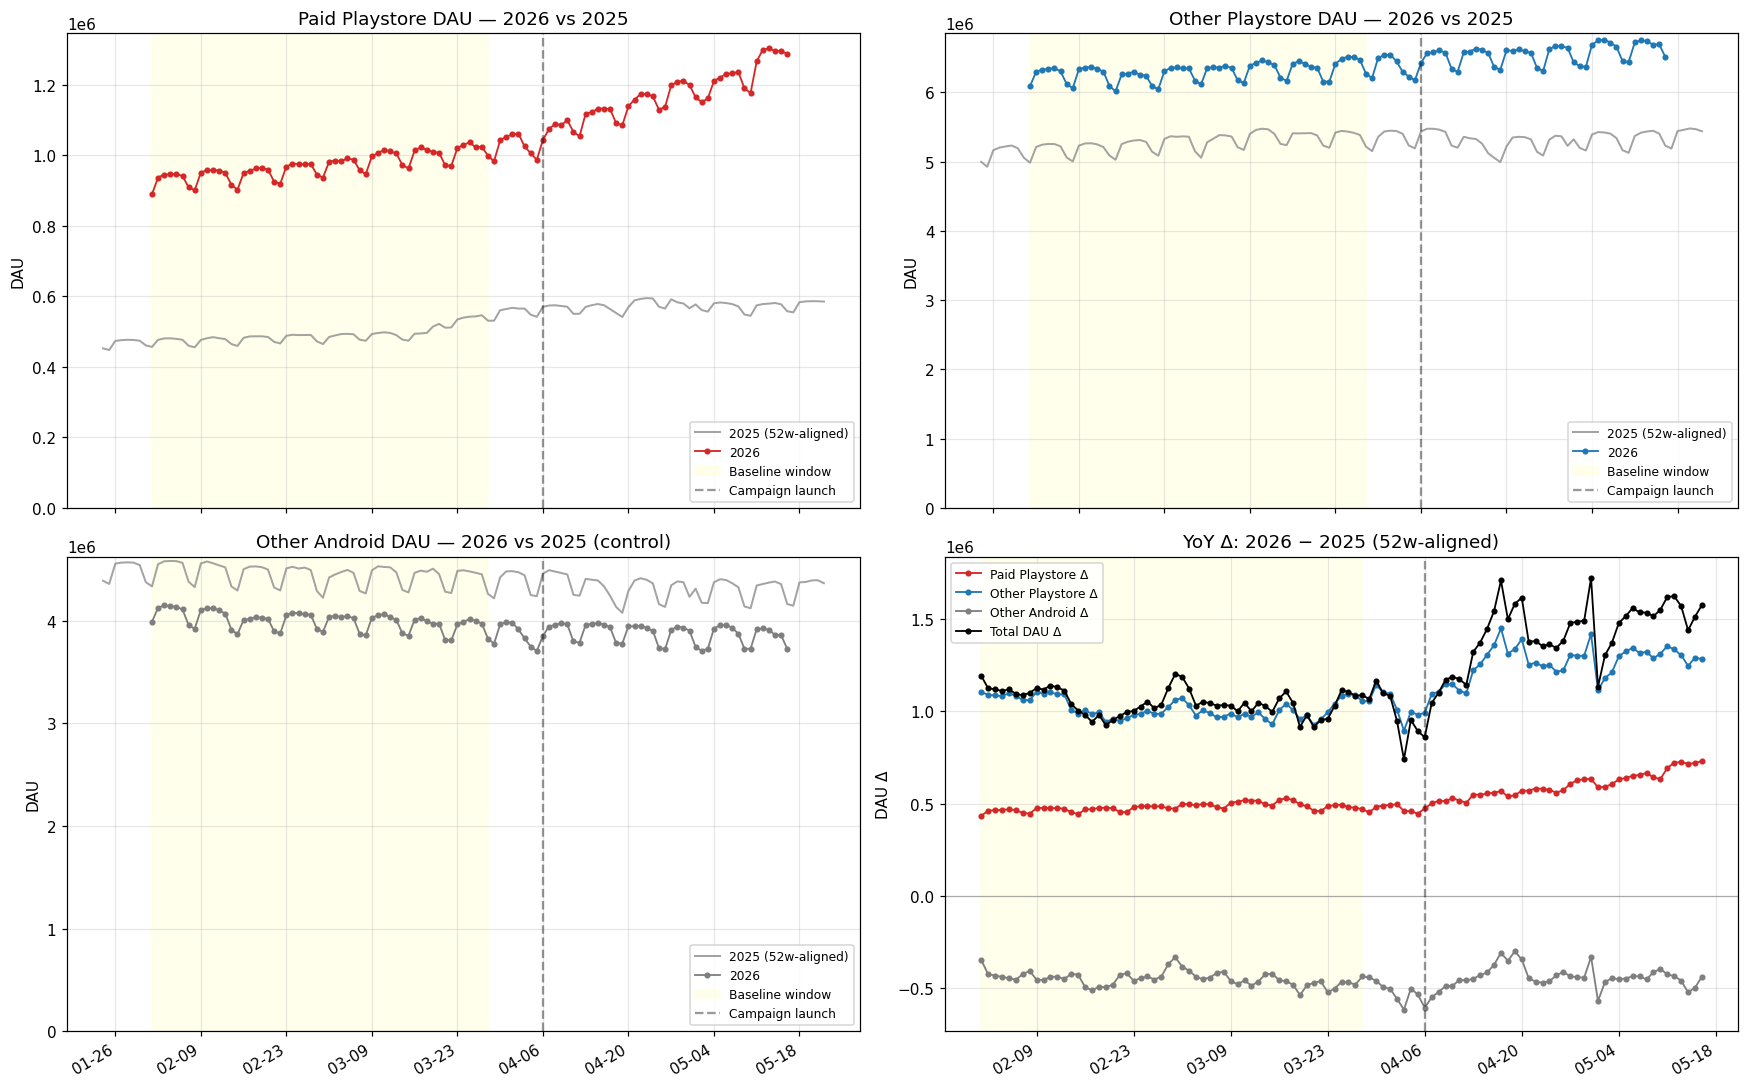

In [28]:
# [plot-dau]
def _bucket_overlay(ax, current, prior, col, color, title):
    ax.plot(prior.index, prior[col], '-', linewidth=1.3, color=PRIOR_YEAR_COLOR, alpha=0.8, label='2025 (52w-aligned)')
    ax.plot(current.index, current[col], 'o-', markersize=3, linewidth=1.2, color=color, label='2026')
    ax.axvspan(BASELINE_START, BASELINE_END, color='lightyellow', alpha=0.6, label='Baseline window')
    ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4, label=f'Campaign launch')
    ax.set_title(title)
    ax.set_ylabel('DAU')
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8, loc='lower right')
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

_bucket_overlay(axes[0, 0], dau_2026, dau_2025_aligned, 'paid_playstore',  PAID_COLOR,    'Paid Playstore DAU — 2026 vs 2025')
_bucket_overlay(axes[0, 1], dau_2026, dau_2025_aligned, 'other_playstore', ORGANIC_COLOR, 'Other Playstore DAU — 2026 vs 2025')
_bucket_overlay(axes[1, 0], dau_2026, dau_2025_aligned, 'other_android',   NULL_COLOR,    'Other Android DAU — 2026 vs 2025 (control)')

# Bottom-right: YoY delta — the seasonality-adjusted lift signal
ax = axes[1, 1]
ax.plot(dau_yoy.index, dau_yoy['paid_playstore'],  'o-', markersize=3, linewidth=1.2, color=PAID_COLOR,    label='Paid Playstore Δ')
ax.plot(dau_yoy.index, dau_yoy['other_playstore'], 'o-', markersize=3, linewidth=1.2, color=ORGANIC_COLOR, label='Other Playstore Δ')
ax.plot(dau_yoy.index, dau_yoy['other_android'],   'o-', markersize=3, linewidth=1.2, color=NULL_COLOR,    label='Other Android Δ')
ax.plot(dau_yoy.index, dau_yoy['total_dau'],       'o-', markersize=3, linewidth=1.2, color='black',      label='Total DAU Δ')
ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
ax.axvspan(BASELINE_START, BASELINE_END, color='lightyellow', alpha=0.6)
ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4)
ax.set_title('YoY Δ: 2026 − 2025 (52w-aligned)')
ax.set_ylabel('DAU Δ')
ax.legend(fontsize=8, loc='upper left')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [29]:
# [query-new-profiles]
# Same 2-year pull pattern as DAU. New profiles is sourced from fenix.new_profiles
# (no reporting lag) and shows the campaign acquisition spike most cleanly.
NEW_PROFILE_SQL = f"""
SELECT
  first_seen_date AS date,
  SUM(IF(paid_vs_organic_gclid = 'Paid', new_profiles, 0)) AS paid_playstore,
  SUM(IF(paid_vs_organic_gclid IS DISTINCT FROM 'Paid'
         AND install_source = 'com.android.vending', new_profiles, 0)) AS other_playstore,
  SUM(IF(paid_vs_organic_gclid IS DISTINCT FROM 'Paid'
         AND (install_source IS NULL OR install_source != 'com.android.vending'),
         new_profiles, 0)) AS other_android,
  SUM(IF(adjust_network = 'Google Ads ACI', new_profiles, 0)) AS adjust_google_ads_aci,
  SUM(new_profiles) AS total_new_profiles
FROM `{NEW_PROFILE_TABLE}`
WHERE (first_seen_date BETWEEN DATE('{DATE_START}') AND DATE('{DATE_END}')
       OR first_seen_date BETWEEN DATE('{PRIOR_DATE_START}') AND DATE('{PRIOR_DATE_END}'))
  AND normalized_channel = '{CHANNEL}'
  AND country != 'IR'
  AND COALESCE(locale, '') NOT LIKE 'fa%'
GROUP BY date
ORDER BY date
"""

np_long = client.query(NEW_PROFILE_SQL).to_dataframe()
np_long['date'] = pd.to_datetime(np_long['date'])
for col in ['paid_playstore', 'other_playstore', 'other_android', 'adjust_google_ads_aci', 'total_new_profiles']:
    np_long[col] = np_long[col].astype(float)

new_profiles_2026, new_profiles_2025_aligned = _split_years(np_long, 'date')

print(f'2026 NPs: {len(new_profiles_2026)} dates, {new_profiles_2026.index.min().date()} to {new_profiles_2026.index.max().date()}')
print(f'2025 NPs (52-week-aligned): {len(new_profiles_2025_aligned)} dates, '
      f'{new_profiles_2025_aligned.index.min().date()} to {new_profiles_2025_aligned.index.max().date()}')

NP_BUCKETS = ['paid_playstore', 'other_playstore', 'other_android', 'total_new_profiles']
np_yoy, np_base, np_post, np_mktg = _summarize_yoy(
    new_profiles_2026, new_profiles_2025_aligned, NP_BUCKETS, label='New profiles'
)


2026 NPs: 105 dates, 2026-02-01 to 2026-05-16
2025 NPs (52-week-aligned): 119 dates, 2026-01-24 to 2026-05-22

--- New profiles: YoY decomposition (2026 minus 52-week-aligned 2025) ---
bucket                          baseline YoY     post-campaign YoY     marketing attrib.
paid_playstore                       +46,914               +77,244               +30,330
other_playstore                      -57,894                -7,717               +50,176
other_android                        -97,527               -69,563               +27,964
total_new_profiles                  -108,507                   -36              +108,471


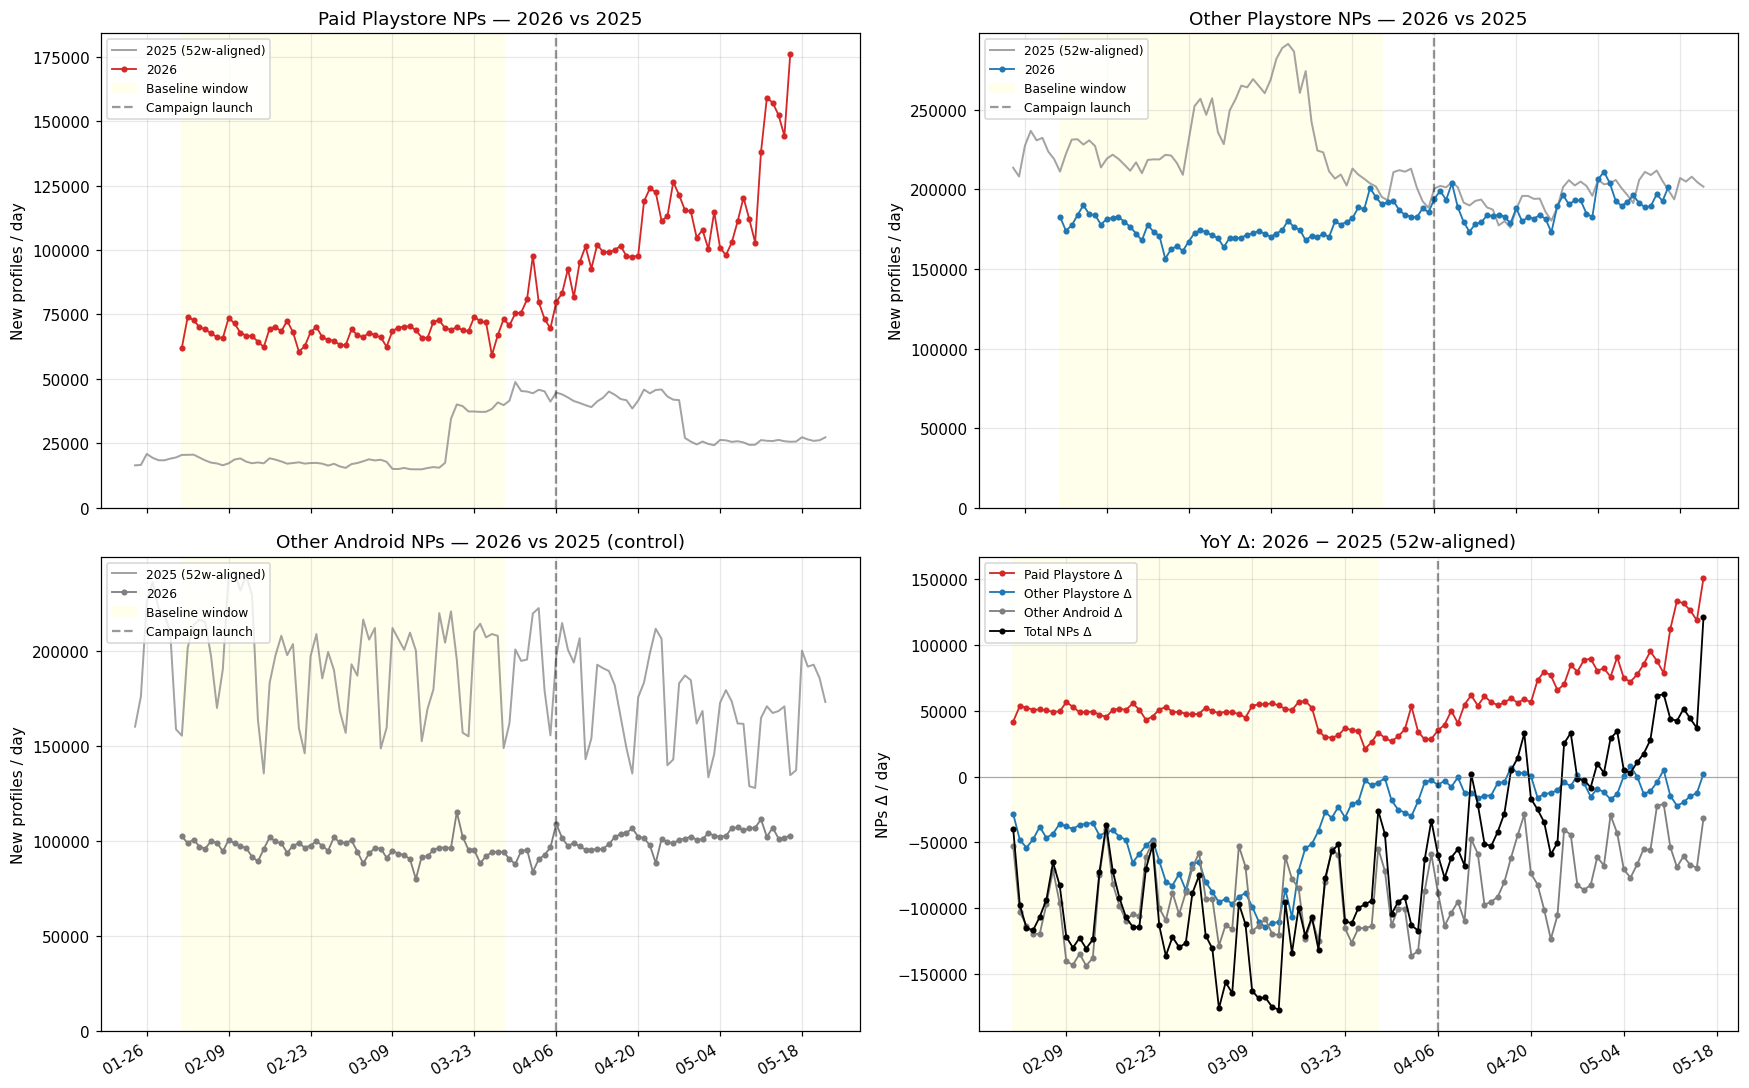

In [30]:
# [plot-new-profiles]
def _np_overlay(ax, current, prior, col, color, title):
    ax.plot(prior.index, prior[col], '-', linewidth=1.3, color=PRIOR_YEAR_COLOR, alpha=0.8, label='2025 (52w-aligned)')
    ax.plot(current.index, current[col], 'o-', markersize=3, linewidth=1.2, color=color, label='2026')
    ax.axvspan(BASELINE_START, BASELINE_END, color='lightyellow', alpha=0.6, label='Baseline window')
    ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4, label=f'Campaign launch')
    ax.set_title(title)
    ax.set_ylabel('New profiles / day')
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8, loc='upper left')
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

_np_overlay(axes[0, 0], new_profiles_2026, new_profiles_2025_aligned, 'paid_playstore',  PAID_COLOR,    'Paid Playstore NPs — 2026 vs 2025')
_np_overlay(axes[0, 1], new_profiles_2026, new_profiles_2025_aligned, 'other_playstore', ORGANIC_COLOR, 'Other Playstore NPs — 2026 vs 2025')
_np_overlay(axes[1, 0], new_profiles_2026, new_profiles_2025_aligned, 'other_android',   NULL_COLOR,    'Other Android NPs — 2026 vs 2025 (control)')

# Bottom-right: YoY delta
ax = axes[1, 1]
ax.plot(np_yoy.index, np_yoy['paid_playstore'],     'o-', markersize=3, linewidth=1.2, color=PAID_COLOR,    label='Paid Playstore Δ')
ax.plot(np_yoy.index, np_yoy['other_playstore'],    'o-', markersize=3, linewidth=1.2, color=ORGANIC_COLOR, label='Other Playstore Δ')
ax.plot(np_yoy.index, np_yoy['other_android'],      'o-', markersize=3, linewidth=1.2, color=NULL_COLOR,    label='Other Android Δ')
ax.plot(np_yoy.index, np_yoy['total_new_profiles'], 'o-', markersize=3, linewidth=1.2, color='black',      label='Total NPs Δ')
ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
ax.axvspan(BASELINE_START, BASELINE_END, color='lightyellow', alpha=0.6)
ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4)
ax.set_title('YoY Δ: 2026 − 2025 (52w-aligned)')
ax.set_ylabel('NPs Δ / day')
ax.legend(fontsize=8, loc='upper left')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()
